In [ ]:
import win32com.client
print('Avvio Inizializzazione')
mcad = win32com.client.Dispatch("MotorCAD.AppAutomation")
mcad.SetVariable('MessageDisplayState', 2)
print('Inizializzazione Completata')
MODEL_PATH = r"C:\Users\grell\Desktop\MCAD_jack\Motori\D106 H65 25sp DT ( 2x0.63 + 2x0.5 ).mot"
mcad.LoadFromFile(MODEL_PATH)

def get_mcad_variables(mcad, var_names=None):
    mapping = {
        'Stator_Lam_Dia': ('Stator_Lam_Dia', 'Stator External diameter'),
        'Stator_Lam_Length': ('Stator_Lam_Length', 'Stator Length'),
        'Number_turns_coil': ('MagTurnsConductor', 'Number of turns per coil'),
        'Slot_number': ('Slot_number', 'Number of slots'),
        'Pole_number': ('Pole_number', 'Number of poles'),
        'MagThrow': ('MagThrow', 'Magnetic throw'),
        'MagPhases': ('MagPhases', 'Number of phases'),
        'Liner_layer_definition': ('Liner_Layers_Definition', 'Liner layer definition (0 = Single_Layer,1 = Double_Layers)'),
        'winding_connection': ('WindingConnection', 'Winding connection type (0: Star, 1: Delta)'),
        'RMScurrentdensity': ('RMScurrentdensity', 'RMS current density in A/mm^2'),
        'ParallelPaths': ('ParallelPaths', 'Number of parallel paths in the winding'),
        'ArmatureTurnCSA': ('ArmatureTurnCSA', 'Armature turn cross-sectional area'),
    }

    keys = list(mapping.keys()) if var_names is None else [k for k in var_names if k in mapping]
    result = {}
    for key in keys:
        mcad_name, desc = mapping[key]
        try:
            val = mcad.GetVariable(mcad_name)[1]
        except Exception:
            val = None
        result[key] = {'value': val, 'description': desc}

    # compute equivalent CSA and store in dict
    from math import sqrt

    def _num(x):
        if x is None:
            return None
        try:
            return float(x)
        except Exception:
            return None

    wc = result.get('winding_connection', {}).get('value')
    atc = result.get('ArmatureTurnCSA', {}).get('value')
    pp = result.get('ParallelPaths', {}).get('value')

    wc_n = _num(wc)
    atc_n = _num(atc)
    pp_n = _num(pp)

    eq_val = None
    if atc_n is not None and pp_n is not None:
        if wc_n is None:
            eq_val = atc_n * pp_n
        else:
            try:
                if int(wc_n) == 0:  # star
                    eq_val = atc_n * pp_n
                elif int(wc_n) == 1:  # delta
                    eq_val = atc_n * pp_n * sqrt(3)
                else:
                    eq_val = atc_n * pp_n
            except Exception:
                eq_val = atc_n * pp_n

    result['Equivalent_CSA'] = {
        'value': eq_val,
        'description': 'Equivalent CSA (mm^2) computed from ArmatureTurnCSA, ParallelPaths and WindingConnection'
    }

    return result

motor_dict= get_mcad_variables(mcad)
print(f"equivalent cross sectional area: {motor_dict['Equivalent_CSA']['value']} mm^2")
# check and build model
model_dict = {
    'Maximum speed': 5000,  # rpm
    'Minimum speed': 50,     # rpm
    'Maximum current density': 15,    # A/mm^2
    'Battery voltage': [24],     # V
    'Current density': [4,4.5,5,5.5,7,7.5,8,13]

}
def check_and_build_model(mcad,motor_dict,model_dict):
    BuildSpeed = mcad.GetVariable('ModelBuildSpeed_MotorLAB')[1]
    BuildCurrent = mcad.GetVariable('MaxModelCurrent_RMS_MotorLAB')[1]
    if BuildSpeed >= model_dict['Maximum speed'] and BuildCurrent >= model_dict['Maximum current density']*motor_dict['Equivalent_CSA']['value']:
        print("Model Already built...\n")
        # Here you would add the code to build the model in MotorCAD
    else:
        print("Building model...\n")
        mcad.SetVariable('ModelBuildSpeed_MotorLAB', model_dict['Maximum speed'])
        mcad.SetVariable('MaxModelCurrent_RMS_MotorLAB', model_dict['Maximum current density']*motor_dict['Equivalent_CSA']['value'])
        mcad.SetVariable('BuildSatModel_MotorLAB', True)
        mcad.SetVariable('BuildLossModel_MotorLAB', True)
        mcad.SetMotorLABContext()
        mcad.BuildModel_Lab()
        mcad.SaveToFile(MODEL_PATH)
        print("Model built and saved.\n")

check_and_build_model(mcad,motor_dict,model_dict)
# ...existing code...
import sqlite3
import hashlib
import json
import numpy as np
import io
import datetime
import os
import scipy.io

DB_PATH = r"c:\Users\grell\Desktop\MCAD_jack\mcad_results.db"
SAVE_KEYS = [
    "Shaft_Torque", "Speed", "Shaft_Power", "Voltage_Phase_RMS",
    "Stator_Current_Line_RMS", "Power_Factor_From_Power_Balance",
    "Efficiency", "Frequency", "DC_Bus_Voltage"
]

def init_db(db_path=DB_PATH):
    con = sqlite3.connect(db_path)
    cur = con.cursor()
    cur.execute("""
    CREATE TABLE IF NOT EXISTS motors(
        id INTEGER PRIMARY KEY,
        motor_hash TEXT UNIQUE,
        motor_json TEXT,
        created_at TEXT
    )""")
    cur.execute(f"""
    CREATE TABLE IF NOT EXISTS runs(
        id INTEGER PRIMARY KEY,
        motor_id INTEGER,
        voltage REAL,
        current_density REAL,
        {" ,".join([f"{k} BLOB" for k in SAVE_KEYS])},
        created_at TEXT,
        FOREIGN KEY(motor_id) REFERENCES motors(id)
    )""")
    con.commit()
    con.close()

def motor_hash(motor_dict):
    h = hashlib.sha256(json.dumps(motor_dict, sort_keys=True).encode("utf-8")).hexdigest()
    return h

def to_blob(arr):
    buf = io.BytesIO()
    np.save(buf, np.asarray(arr))
    return buf.getvalue()

def from_blob(blob):
    buf = io.BytesIO(blob)
    buf.seek(0)
    return np.load(buf, allow_pickle=True)

def get_motor_id(con, mhash, motor_dict):
    cur = con.cursor()
    cur.execute("SELECT id FROM motors WHERE motor_hash=?", (mhash,))
    row = cur.fetchone()
    if row:
        return row[0]
    cur.execute("INSERT INTO motors(motor_hash,motor_json,created_at) VALUES (?,?,?)",
                (mhash, json.dumps(motor_dict), datetime.datetime.utcnow().isoformat()))
    con.commit()
    return cur.lastrowid

def get_run_row(con, motor_id, voltage, current_density):
    cur = con.cursor()
    cur.execute("SELECT * FROM runs WHERE motor_id=? AND voltage=? AND current_density=?",
                (motor_id, float(voltage), float(current_density)))
    return cur.fetchone()

def save_run(con, motor_id, voltage, current_density, mat_data):
    cur = con.cursor()
    blobs = []
    for k in SAVE_KEYS:
        val = mat_data.get(k, None)
        blobs.append(to_blob(val) if val is not None else None)
    cols = "motor_id,voltage,current_density," + ",".join(SAVE_KEYS) + ",created_at"
    placeholders = ",".join(["?"] * (3 + len(SAVE_KEYS) + 1))
    cur.execute(f"INSERT INTO runs({cols}) VALUES ({placeholders})",
                (motor_id, float(voltage), float(current_density), *blobs, datetime.datetime.utcnow().isoformat()))
    con.commit()

def load_run_data(con, motor_id, voltage, current_density):
    row = get_run_row(con, motor_id, voltage, current_density)
    if not row:
        return None
    # columns: id,motor_id,voltage,current_density,<SAVE_KEYS...>,created_at
    offset = 4
    data = {}
    for i, k in enumerate(SAVE_KEYS):
        blob = row[offset + i]
        data[k] = from_blob(blob) if blob is not None else None
    return data

def arrays_equal(a, b, rtol=1e-4, atol=1e-4):
    if a is None or b is None:
        return False
    a = np.asarray(a)
    b = np.asarray(b)
    if a.shape != b.shape:
        return False
    return np.allclose(a, b, rtol=rtol, atol=atol)

def run_mcad_and_load(mcad, V, J, motor_dict, model_path):
    # set variables for a single run, run MCAD and load .mat
    mcad.SetVariable("EmagneticCalcType_Lab", 0)
    mcad.SetVariable("DCBusVoltage", V)
    mcad.SetVariable("ModulationIndex_MotorLAB", 0.95)
    mcad.SetVariable("CurrentSpec_MotorLAB", 1)
    mcad.SetVariable("CurrentDefinition", 1)
    mcad.SetVariable("Imax_RMS_MotorLAB", J * motor_dict['Equivalent_CSA']['value'])
    mcad.SetVariable("SpeedMax_MotorLAB", model_dict['Maximum speed'])
    mcad.SetVariable('Speedinc_MotorLAB', 50)
    mcad.SetVariable('SpeedMin_MotorLAB', model_dict['Minimum speed'])
    mcad.SetVariable("AutoShowResults_MotorLAB", True)
    mcad.CalculateMagnetic_Lab()
    # load mat
    model_folder_path = os.path.splitext(model_path)[0]
    mat_file_simple = os.path.join(model_folder_path, 'Lab', 'MotorLAB_elecdata.mat')
    data = scipy.io.loadmat(mat_file_simple)
    # extract required keys; ensure arrays or None
    out = {}
    for k in SAVE_KEYS:
        out[k] = data.get(k, None)
    return out

def run_sweep_with_db(mcad, model_dict, motor_dict, model_path, db_path=DB_PATH):
    init_db(db_path)
    con = sqlite3.connect(db_path)
    mhash = motor_hash(motor_dict)
    motor_id = get_motor_id(con, mhash, motor_dict)
    results = []
    model_folder_path = os.path.splitext(model_path)[0]

    for V in model_dict['Battery voltage']:
        J_list = model_dict['Current density']
        if not J_list:
            continue
        J0 = J_list[0]
        existing = get_run_row(con, motor_id, V, J0)
        # Always run first density to compare if DB had an entry
        try:
            first_mat = run_mcad_and_load(mcad, V, J0, motor_dict, model_path)
        except Exception as e:
            print(f"Error running first J for V={V}, J={J0}: {e}")
            continue

        if existing:
            stored = load_run_data(con, motor_id, V, J0)
            # compare key arrays (Shaft_torque, shaft_power, efficiency) + speed
            same = True
            for k in ("Shaft_Torque", "Shaft_Power", "Efficiency", "Speed"):
                if not arrays_equal(stored.get(k), first_mat.get(k)):
                    same = False
                    break
            if same:
                print(f"Existing results match for motor {mhash} V={V} J={J0} -> skipping other J for this V")
                # do not save and skip other J for this voltage
                results.append({'BatteryVoltage': V, 'skipped': True})
                continue
            else:
                print(f"Existing results DIFFER for motor {mhash} V={V} J={J0} -> running full sweep and will save")
        else:
            print(f"No existing record for motor {mhash} V={V} J={J0} -> running full sweep and will save")

        # run full sweep for this voltage and save each run
        for J in J_list:
            try:
                mat_data = run_mcad_and_load(mcad, V, J, motor_dict, model_path)
                save_run(con, motor_id, V, J, mat_data)
                results.append({'BatteryVoltage': V, 'CurrentDensity': J, 'mat': mat_data})
                print(f"Saved V={V}, J={J}")
            except Exception as e:
                print(f"Error for V={V}, J={J}: {e}")

    con.close()
    return results

# replace prior call with:
# MODEL_PATH already defined in notebook
data_simple = run_sweep_with_db(mcad, model_dict, motor_dict, MODEL_PATH)
# ...existing code...
mcad.quit()

Avvio Inizializzazione
Inizializzazione Completata


0

[{'id': 1, 'hash': '809ad2403e5780deb5bd26e555074d79ac198234ad1f33f77eb5a5a227e29c4e', 'created_at': '2026-02-08T19:40:04.845604', 'motor_json': {'Stator_Lam_Dia': {'value': 106.5, 'description': 'Stator External diameter'}, 'Stator_Lam_Length': {'value': 65.0, 'description': 'Stator Length'}, 'Number_turns_coil': {'value': 25, 'description': 'Number of turns per coil'}, 'Slot_number': {'value': 24, 'description': 'Number of slots'}, 'Pole_number': {'value': 4, 'description': 'Number of poles'}, 'MagThrow': {'value': 7, 'description': 'Magnetic throw'}, 'MagPhases': {'value': 3, 'description': 'Number of phases'}, 'Liner_layer_definition': {'value': 0, 'description': 'Liner layer definition (0 = Single_Layer,1 = Double_Layers)'}, 'winding_connection': {'value': 1, 'description': 'Winding connection type (0: Star, 1: Delta)'}, 'RMScurrentdensity': {'value': 1.0035689774306031, 'description': 'RMS current density in A/mm^2'}, 'ParallelPaths': {'value': 2, 'description': 'Number of parall

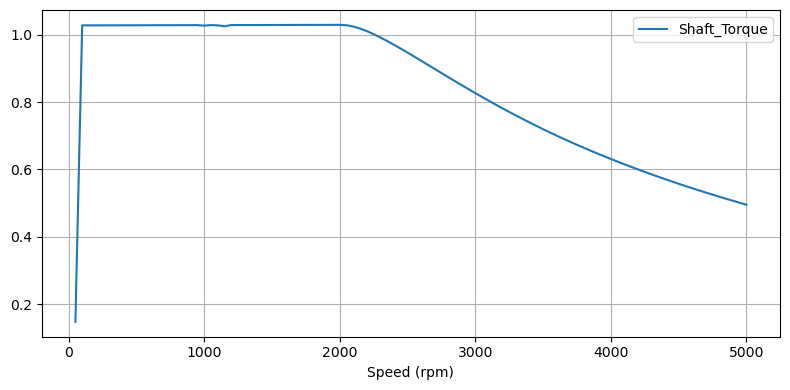

In [23]:
# Python
import sqlite3
import json
import io
import numpy as np
import matplotlib.pyplot as plt
import datetime

DB_PATH = r"c:\Users\grell\Desktop\MCAD_jack\mcad_results.db"
SAVE_KEYS = [
    "Shaft_Torque", "Speed", "Shaft_Power", "Voltage_Phase_RMS",
    "Stator_Current_Line_RMS", "Power_Factor_From_Power_Balance",
    "Efficiency", "Frequency", "DC_Bus_Voltage"
]

def from_blob(blob):
    if blob is None:
        return None
    buf = io.BytesIO(blob)
    buf.seek(0)
    return np.load(buf, allow_pickle=True)

def list_motors(db_path=DB_PATH):
    con = sqlite3.connect(db_path)
    cur = con.cursor()
    cur.execute("SELECT id, motor_hash, created_at, motor_json FROM motors ORDER BY id")
    rows = cur.fetchall()
    con.close()
    motors = []
    for r in rows:
        try:
            mj = json.loads(r[3])
        except Exception:
            mj = r[3]
        motors.append({'id': r[0], 'hash': r[1], 'created_at': r[2], 'motor_json': mj})
    return motors

def list_runs_for_motor(motor_id, db_path=DB_PATH):
    con = sqlite3.connect(db_path)
    cur = con.cursor()
    cur.execute("SELECT id, voltage, current_density, created_at FROM runs WHERE motor_id=? ORDER BY voltage, current_density", (int(motor_id),))
    rows = cur.fetchall()
    con.close()
    return [{'run_id': r[0], 'voltage': r[1], 'current_density': r[2], 'created_at': r[3]} for r in rows]

def load_run(motor_id, voltage, current_density, db_path=DB_PATH):
    con = sqlite3.connect(db_path)
    cur = con.cursor()
    cur.execute("SELECT * FROM runs WHERE motor_id=? AND voltage=? AND current_density=?", (int(motor_id), float(voltage), float(current_density)))
    row = cur.fetchone()
    con.close()
    if not row:
        return None
    # columns: id,motor_id,voltage,current_density,<SAVE_KEYS...>,created_at
    offset = 4
    data = {}
    for i, k in enumerate(SAVE_KEYS):
        blob = row[offset + i]
        data[k] = from_blob(blob) if blob is not None else None
    return data

def summarize_run(data):
    if data is None:
        print("No data")
        return
    for k in SAVE_KEYS:
        v = data.get(k)
        if v is None:
            print(f"{k}: None")
        else:
            arr = np.asarray(v)
            print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")

def plot_run(data, show=['Shaft_Torque','Shaft_Power','Efficiency']):
    if data is None:
        print("No data")
        return
    speed = data.get('Speed')
    if speed is None:
        print("No speed array to plot")
        return
    speed = np.asarray(speed).flatten()
    plt.figure(figsize=(8,4))
    for key in show:
        arr = data.get(key)
        if arr is None:
            continue
        y = np.asarray(arr).flatten()
        plt.plot(speed, y, label=key)
    plt.xlabel('Speed (rpm)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Esempio d'uso:
motors = list_motors(); print(motors)
runs = list_runs_for_motor(motor_id=1); print(runs)
data = load_run(motor_id=1, voltage=24, current_density=4)
summarize_run(data)
plot_run(data, show=['Shaft_Torque'])